# Spam|Ham Classification System 
### We are picking the  dataset from the kaggle and Building the classification System on it. We will try to build the best accurate and precise system.
## Dataset Url: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
# Steps:
## 1 Preprocessings
* Remove Null values if any
* Remove Duplicate values if any
* Converting all the alphabests to Lower case
* Tokenizing
* Removing Special characters (@,#,$,%,... etc )
* Removing Stop words (is, the, of, ... etc)
* Removing all the Punctuations
* Stemming: (dancing, dances --> dance  etc)

## 2 EDA 
* Analyzing Data through Graphs etc

## 3 Model Selection 
* Analyzing different Models performance then Select the best fit

## 4 Model Evaluation 
* Tuning The Model




In [1]:
import pandas as pd      ## for data manipulations
import sklearn as sks         ## for importing models 
import matplotlib.pyplot as plt  ## for basic visualization 
import seaborn as sns    ## for advance visualization
import numpy as np       ## for mathematical operations

In [2]:
df = pd.read_csv("spam.csv", encoding="latin1")

# Lets start with the Step1: Preprocessings

##

In [3]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Remove the unwanted and Columns from the dataset

In [4]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)

In [5]:
df.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Lets remove duplicates if any 

In [6]:
df.duplicated().sum()

np.int64(403)

In [7]:
df.drop_duplicates(inplace= True)

## Renaming the Columns v1 & v2 with the proper names

In [8]:
df.rename(columns=
          {'v1' : 'target', 
            'v2':'text'
          }, inplace=True)


In [9]:
df.head(3)

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...


##  Encode the target col with 0 or 1, we will use lable enconding

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
le=LabelEncoder()
df["target"]=le.fit_transform(df["target"])

In [12]:
df.head(3)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...


## lets create some other columns from the `text` column For Feature slection 

In [13]:
df['alphabets_length']=df['text'].str.len()

In [14]:
df.head(3)

,target,text,alphabets_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155


In [15]:
import nltk ## NLP liabrary for different operations on words, sentences etc 

In [16]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\SHAN
[nltk_data]     ALI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [17]:
df['words_length']=df['text'].str.strip().str.split().str.len()   ## (str for string,  strip for extra spaces, )

In [18]:
df.head(3)

,target,text,alphabets_length,words_length
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28


In [19]:
from nltk.tokenize  import sent_tokenize, word_tokenize

In [20]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\SHAN
[nltk_data]     ALI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
df['sentence_length']=df['text'].apply(lambda x: len(sent_tokenize(x)))

In [22]:
df.sample(3)

,target,text,alphabets_length,words_length,sentence_length
4157,0,It certainly puts things into perspective when...,74,11,1
3203,0,She's good. How are you. Where r u working now,46,10,3
3056,0,Just woke up. Yeesh its late. But I didn't fal...,74,15,3


# EDA 

In [23]:
df.shape

(5169, 5)

In [24]:
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

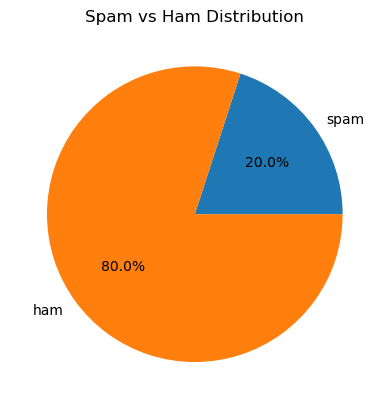

In [25]:
labels = ['spam', 'ham']
sizes = [200, 800]   # example counts

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Spam vs Ham Distribution")

plt.show()

## Feature selection we will use different methods to pick the best features

## lets see throgh the corelation heatmap 

In [26]:
df.head(3)

,target,text,alphabets_length,words_length,sentence_length
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2


In [27]:
corr= df[['alphabets_length', 'words_length', 'sentence_length', 'target']].corr()

<function matplotlib.pyplot.show(close=None, block=None)>

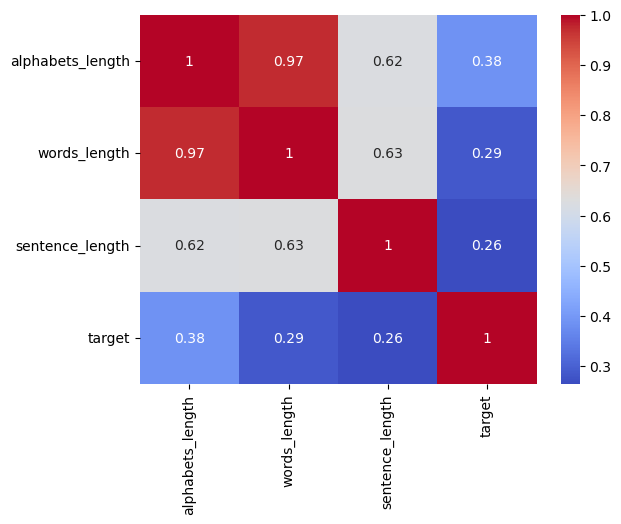

In [28]:
sns.heatmap(corr, annot=True, cmap='coolwarm' )
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

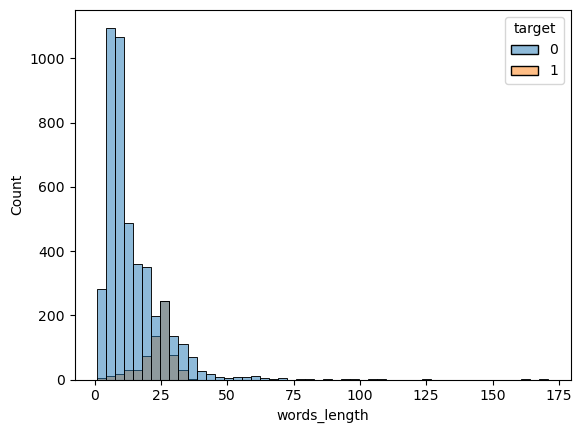

In [29]:
sns.histplot(data=df, x='words_length', hue='target', bins=50)
plt.show

### it seems these features don't have best relation with the target, so we can ignore them and go woth the `"text"` only

## Lets do all the 'Text Preprocessings' through a single function  

In [30]:
import string 
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [32]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []    ## empty list to append the text, bcz this func is returning the list
    for i in text:
        if i.isalnum():    ## if there is any special character it will remove it , it will only take alpha numeric values
            y.append(i)

    text = y[:]    # List is mutable datatype , it can not be directry copy, we can just make a clone of it like y[:], [:] says take all the data 
    y.clear()     # clear y list for further storing data

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation: 
            y.append(i)

    text= y[:]
    y.clear()

    for i in text: 
        y.append(ps.stem(i))

    return" ".join(y)   # returning the string.. acutally joining whatever inside 'y' to the returning string
          

    





In [49]:
df['text']= df['text'].apply(transform_text)   ## applied function on the datset 

In [36]:
df.head(5)

,target,text,alphabets_length,words_length,sentence_length
0,0,go jurong point crazi avail bugi n great world...,111,20,2
1,0,ok lar joke wif u oni,29,6,2
2,1,free entri 2 wkli comp win fa cup final tkt 21...,155,28,2
3,0,u dun say earli hor u c alreadi say,49,11,1
4,0,nah think goe usf live around though,61,13,1


## Starting with the Vectorization 
* `We have choosen TF-IDF (Term Frequency – Inverse Document Frequency) vectorizer to convert text data into numerical form so that machine learning models can understand it.`
* `Unlike other methods, TF-IDF not only counts how often a word appears in a document, but also reduces the importance of commonly occurring words that are less useful for classification.`
* `Words that appear frequently in a specific message but rarely in other messages are considered more important.`

In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [107]:
tfidf= TfidfVectorizer(max_features=3000, ngram_range=(1,2))

In [108]:
x = tfidf.fit_transform(df['text'])

In [109]:
y = df['target']

### Splitting the the columns `(x & y)` data into 80% training and the 20% testing.

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2, random_state=42)

### Training models... we have choosed 4 models according to our data. 
* `NaiveBayes:` works best in text classification.
* `XGBoost:`  works best on text classification. --> *we will not used it here as it doesn't work on sparce matrix*
* `LogisticRegression:` works best in classification and on unbalanced data
*  `SVM:` works best in classification and on unbalanced data

### Lets see the best fit model for our project

In [112]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score

In [141]:
## creating dictionary for models to train atonce 

models = {
    'Naive Bayes':MultinomialNB(alpha=0.1, fit_prior=True),
    'Logistic Regression':LogisticRegression(C=10, penalty='l2', max_iter= 1000, solver='lbfgs'),
    'SVM':LinearSVC(C=1, loss= 'squared_hinge'), 
}

##  We are Dealing with unbalanced Data so we have to `GO` with `Precision` insted of accuracy !

In [142]:
## using loop for train models one by one &  see id there is overfitting or under fitting 

for name, model in models.items():
    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred  = model.predict(x_test)
    print( name)
    print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("F1-score:", f1_score(y_test, y_test_pred))
    print("-"*30)


Naive Bayes
Training Accuracy: 0.9898428053204353
Testing Accuracy: 0.9777562862669246
Precision: 0.9621212121212122
Recall: 0.8758620689655172
F1-score: 0.9169675090252708
------------------------------
Logistic Regression
Training Accuracy: 0.9956469165659009
Testing Accuracy: 0.9816247582205029
Precision: 0.9846153846153847
Recall: 0.8827586206896552
F1-score: 0.9309090909090909
------------------------------
SVM
Training Accuracy: 0.9973397823458283
Testing Accuracy: 0.9825918762088974
Precision: 0.9774436090225563
Recall: 0.896551724137931
F1-score: 0.935251798561151
------------------------------


## we are having overall good perofromance of models but lets tune the models to see if there is a change in the performance. 
## *we will use `GridSearchCv` to see the best parameters for the model*

In [125]:
from sklearn.model_selection import GridSearchCV

In [127]:
# for the NaiveBayes
nb = MultinomialNB()
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 2.0],
    'fit_prior': [True, False]
}

grid_nb = GridSearchCV(nb, param_grid, scoring='f1', cv=5)
grid_nb.fit(x_train, y_train)

print("Best NaiveBayes Params:", grid_nb.best_params_)
print("Best NaiveBayes Score:", grid_nb.best_score_)

Best NaiveBayes Params: {'alpha': 0.1, 'fit_prior': True}
Best NaiveBayes Score: 0.9223102374280723


In [128]:
lr = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(lr, param_grid, scoring='f1', cv=5)
grid_lr.fit(x_train, y_train)

print("Best LogicRegression Params:", grid_lr.best_params_)
print("Best LogisticRegression Score:", grid_lr.best_score_)

Best LogicRegression Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LogisticRegression Score: 0.9055545596185585


In [130]:
svm = LinearSVC()

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'loss': ['hinge', 'squared_hinge']
}

grid_svm = GridSearchCV(svm, param_grid, scoring='f1', cv=5)
grid_svm.fit(x_train, y_train)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM Score:", grid_svm.best_score_)

Best SVM Params: {'C': 1, 'loss': 'squared_hinge'}
Best SVM Score: 0.9250584035369348


# we should go with the SVM, which has overall best performance 

In [143]:
model= LinearSVC(C=1, loss= 'squared_hinge')
model.fit(x_train,y_train)

LinearSVC(C=1)

## we are saving the Tokenization and Trained model to use it in the prediction system.

In [147]:
import pickle

In [149]:
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(model, open('trained_model.pkr', 'wb'))